# FactoryBench, Evaluation Analysis from Opik Traces

This notebook retrieves evaluation traces from [Opik](https://www.comet.com/opik) and generates
publication-quality figures for the FactoryBench benchmark.

In [50]:
import os
import json
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
warnings.filterwarnings("ignore", category=FutureWarning)

# Forgis brand palette 
TIGER    = "#FF5A00"
FIRE     = "#FF4D00"
FLICKER  = "#DC4B07"
STEEL    = "#878F92"
GUNMETAL = "#122128"
PANEL    = "#202E35"
BLUE     = "#3A7BD5"
GREEN    = "#2ECC71"

MODEL_COLORS = {
    "gpt-5-mini":       TIGER,
    "claude-haiku-4-5": BLUE,
    "deepseek-v3.1":    GREEN,
    "mistral-large-3":  FLICKER,
}

FORGIS_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "forgis", ["#FFFFFF", "#FFD6B8", TIGER, FLICKER, GUNMETAL],
)

FORMAT_LABELS = {
    "multiple_choice_single_select": "MCQ",
    "multiple_choice_multi_select":  "MCQ (Multi)",
    "numerical":                     "Numerical",
    "tensor":                        "Tensor",
    "ranking":                       "Ranking",
    "free_form":                     "Free Form",
}

FORMAT_ORDER  = ["MCQ", "MCQ (Multi)", "Numerical", "Tensor", "Ranking", "Free Form"]
LEVEL_ORDER   = ["level_1", "level_2", "level_3", "level_4"]
LEVEL_LABELS  = {"level_1": "L1 State", "level_2": "L2 Intervention", "level_3": "L3 Counterfactual", "level_4": "L4 Decision"}
DIFF_ORDER    = ["easy", "medium", "hard"]

FIGURES_DIR = Path("outputs/evaluation_figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def set_neurips_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "axes.linewidth": 0.8,
        "axes.edgecolor": GUNMETAL,
        "axes.labelcolor": GUNMETAL,
        "xtick.color": GUNMETAL,
        "ytick.color": GUNMETAL,
        "text.color": GUNMETAL,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    })


set_neurips_style()
print("Setup complete.")

Setup complete.


## 1, Fetch traces from Opik

In [51]:
import opik

OPIK_PROJECT = os.getenv("OPIK_PROJECT_NAME")
OPIK_WORKSPACE = os.getenv("OPIK_WORKSPACE")

client = opik.Opik(
    project_name=OPIK_PROJECT,
    workspace=OPIK_WORKSPACE,
)

print(f"Connected to Opik project='{OPIK_PROJECT}' workspace='{OPIK_WORKSPACE}'")
print("Fetching traces (this may take a moment)...")

traces = client.search_traces(
    project_name=OPIK_PROJECT, max_results=100000, filter_string='start_time > "2026-04-17T03:58:00Z"'
)

print(f"Fetched {len(traces)} traces.")

Connected to Opik project='FactoryBench' workspace='forgis'
Fetching traces (this may take a moment)...
Fetched 898 traces.


## 2, Build a DataFrame from traces

In [52]:
# Normalize dated model IDs to their short form
MODEL_ALIASES = {
    "gpt-5-mini-2025-08-07": "gpt-5-mini",
    "claude-haiku-4-5-20251001": "claude-haiku-4-5", 
}

# TS foundation models are evaluated on a smaller subset (only prediction
# questions), so we keep them out of the main `df`, they get their own
# figures at the end. Any trace tagged `ts_foundation` or whose model is one
# of these IDs is rerouted.
TS_MODEL_IDS = {"chronos-2", "moirai"}

def _tw_key(tw):
    """Normalize time_window metadata into a stable tuple suitable for matching."""
    if tw is None:
        return None
    if isinstance(tw, (list, tuple)) and len(tw) == 2:
        try:
            return (round(float(tw[0]), 3), round(float(tw[1]), 3))
        except Exception:
            return tuple(tw)
    return tw

rows = []

for trace in traces:
    metadata = trace.metadata or {}
    tags = set(trace.tags or [])
    feedback = {fb.name: fb.value for fb in (trace.feedback_scores or [])}
    inp = trace.input or {}

    raw_model = (metadata.get("model") or "unknown").lower()
    model_name = MODEL_ALIASES.get(raw_model, raw_model)

    # Skip TS foundation traces, they are handled in the dedicated section.
    if "ts_foundation" in tags or model_name in TS_MODEL_IDS:
        continue

    answer_format_raw = metadata.get("answer_format", "unknown")
    answer_format = FORMAT_LABELS.get(answer_format_raw, answer_format_raw)

    # Derive level from tags
    level = "unknown"
    for tag in tags:
        if tag.startswith("level_"):
            level = tag
            break

    # Derive difficulty from tags or metadata
    difficulty = ""
    for d in DIFF_ORDER:
        if d in tags:
            difficulty = d
            break

    accuracy = feedback.get("accuracy")
    llm_judge = feedback.get("llm_judge")

    rows.append({
        "trace_id":      trace.id,
        "model":         model_name,
        "level":         level,
        "answer_format": answer_format,
        "difficulty":    difficulty,
        "question_type": metadata.get("question_type", "unknown"),
        "dataset":       metadata.get("dataset", ""),
        "episode":       metadata.get("episode", ""),
        "time_window":   _tw_key(metadata.get("time_window")),
        "accuracy":      accuracy,
        "llm_judge":     llm_judge,
        "prediction":    inp.get("prediction", ""),
        "ground_truth":  inp.get("ground_truth", ""),
        "cost":          trace.total_estimated_cost or 0.0,
    })

df = pd.DataFrame(rows)

# Drop rows without a score
df = df.dropna(subset=["accuracy"])
df["accuracy"] = df["accuracy"].astype(float)

print(f"DataFrame shape (chat LLMs only): {df.shape}")
print(f"Models:  {sorted(df['model'].unique())}")
print(f"Levels:  {sorted(df['level'].unique())}")
print(f"Formats: {sorted(df['answer_format'].unique())}")
print(f"Trazas sin time_window: {df['time_window'].isna().sum()}")
if df['difficulty'].any():
    print(f"Difficulties: {sorted(df[df['difficulty'] != '']['difficulty'].unique())}")
df.head()

DataFrame shape (chat LLMs only): (880, 14)
Models:  ['claude-haiku-4-5', 'deepseek-v3.1', 'gpt-5-mini', 'mistral-large-3']
Levels:  ['level_1', 'level_2', 'level_3']
Formats: ['MCQ', 'MCQ (Multi)', 'Numerical', 'Ranking', 'Tensor']
Trazas sin time_window: 400


,trace_id,model,level,answer_format,difficulty,question_type,dataset,episode,time_window,accuracy,llm_judge,prediction,ground_truth,cost
0,019db6b6-fe83-7453-9099-53cda418fd35,mistral-large-3,level_3,Ranking,,predictive,aursad,aursad_009,None,0.166667,None,BCAD,ADCB,0.295545
1,019db6b6-e901-72d8-b76f-e35d3bfc7ed3,mistral-large-3,level_3,Ranking,,predictive,aursad,aursad_019,None,0.166667,None,BCAD,ADCB,0.213840
2,019db6b6-dcc0-7489-a866-c0eade2053fe,mistral-large-3,level_3,Ranking,,predictive,aursad,aursad_009,None,0.166667,None,BCDA,ACDB,0.273880
3,019db6b6-ca7e-7662-9353-9be8a01f1a82,mistral-large-3,level_3,Ranking,,predictive,aursad,aursad_025,None,0.666667,None,BCAD,BDCA,0.245530
4,019db6b6-b9fe-7c39-9441-15c0399def95,mistral-large-3,level_3,Ranking,,predictive,aursad,aursad_016,None,0.666667,None,BCAD,BDCA,0.158640


## 3, Heatmap: Models × Levels

In [53]:
def plot_heatmap(pivot_df, title, xlabel, ylabel, filename, col_labels=None, figsize=None):
    """Generic heatmap with count annotations."""
    if pivot_df.empty:
        print(f"Skipping {title}: no data.")
        return

    n_rows, n_cols = pivot_df.shape
    if figsize is None:
        figsize = (max(6, n_cols * 1.8), max(3, n_rows * 1.2 + 1))

    # Build annotation matrix with counts
    annot = pivot_df.copy().astype(object)
    for model in pivot_df.index:
        for col in pivot_df.columns:
            val = pivot_df.loc[model, col]
            mask = (df["model"] == model)
            if col in LEVEL_LABELS.values():
                # Reverse lookup level key
                level_key = [k for k, v in LEVEL_LABELS.items() if v == col]
                if level_key:
                    mask = mask & (df["level"] == level_key[0])
            elif col in FORMAT_ORDER:
                mask = mask & (df["answer_format"] == col)
            elif col in DIFF_ORDER:
                mask = mask & (df["difficulty"] == col)
            n = mask.sum()
            if pd.isna(val):
                annot.loc[model, col] = ""
            else:
                annot.loc[model, col] = f"{val:.1f}\n(n={n})"

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        pivot_df.values.astype(float),
        annot=annot.values,
        fmt="",
        cmap=FORGIS_CMAP,
        vmin=0, vmax=100,
        linewidths=1.5, linecolor="white",
        cbar_kws={"label": "Accuracy (%)", "shrink": 0.8},
        ax=ax,
        mask=pd.isna(pivot_df.values.astype(float)),
        xticklabels=col_labels if col_labels else pivot_df.columns.tolist(),
        yticklabels=pivot_df.index.tolist(),
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold", pad=14)
    fig.tight_layout()
    out = FIGURES_DIR / filename
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

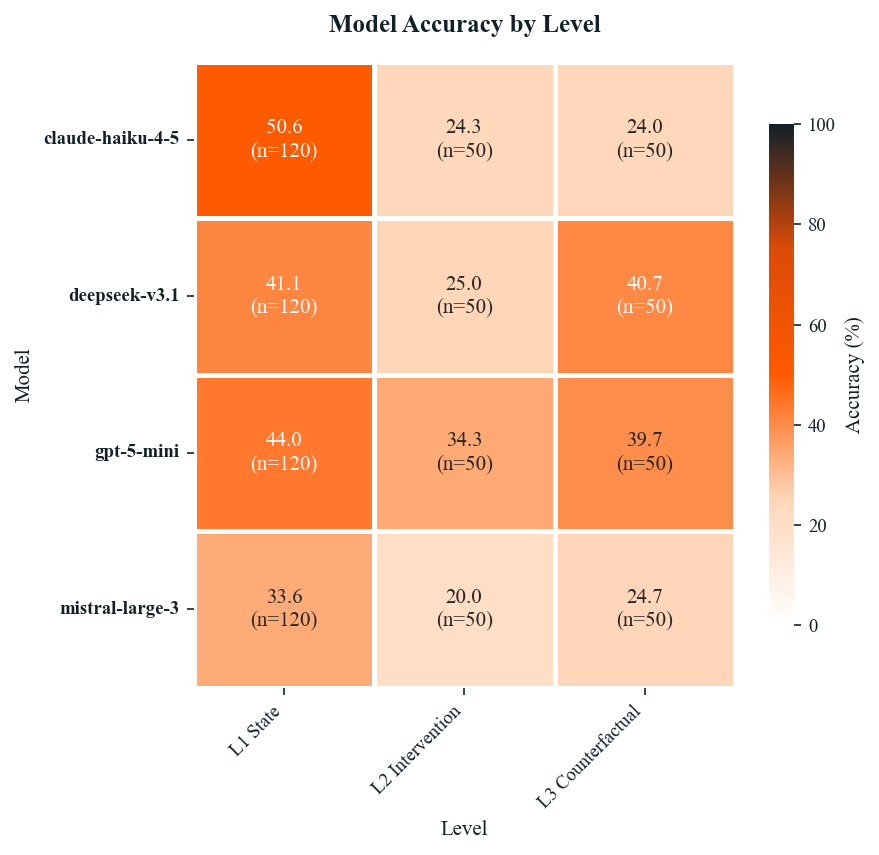

Saved: outputs\evaluation_figures\heatmap_models_x_levels.png


In [54]:
# Heatmap 1: Models × Levels
pivot_levels = df.groupby(["model", "level"])["accuracy"].mean().unstack() * 100

# Reorder columns
level_cols = [l for l in LEVEL_ORDER if l in pivot_levels.columns]
pivot_levels = pivot_levels[level_cols]
pivot_levels.columns = [LEVEL_LABELS.get(c, c) for c in pivot_levels.columns]

plot_heatmap(
    pivot_levels,
    title="Model Accuracy by Level",
    xlabel="Level",
    ylabel="Model",
    filename="heatmap_models_x_levels.png",
)

## 4, Heatmap: Models × Answer Formats

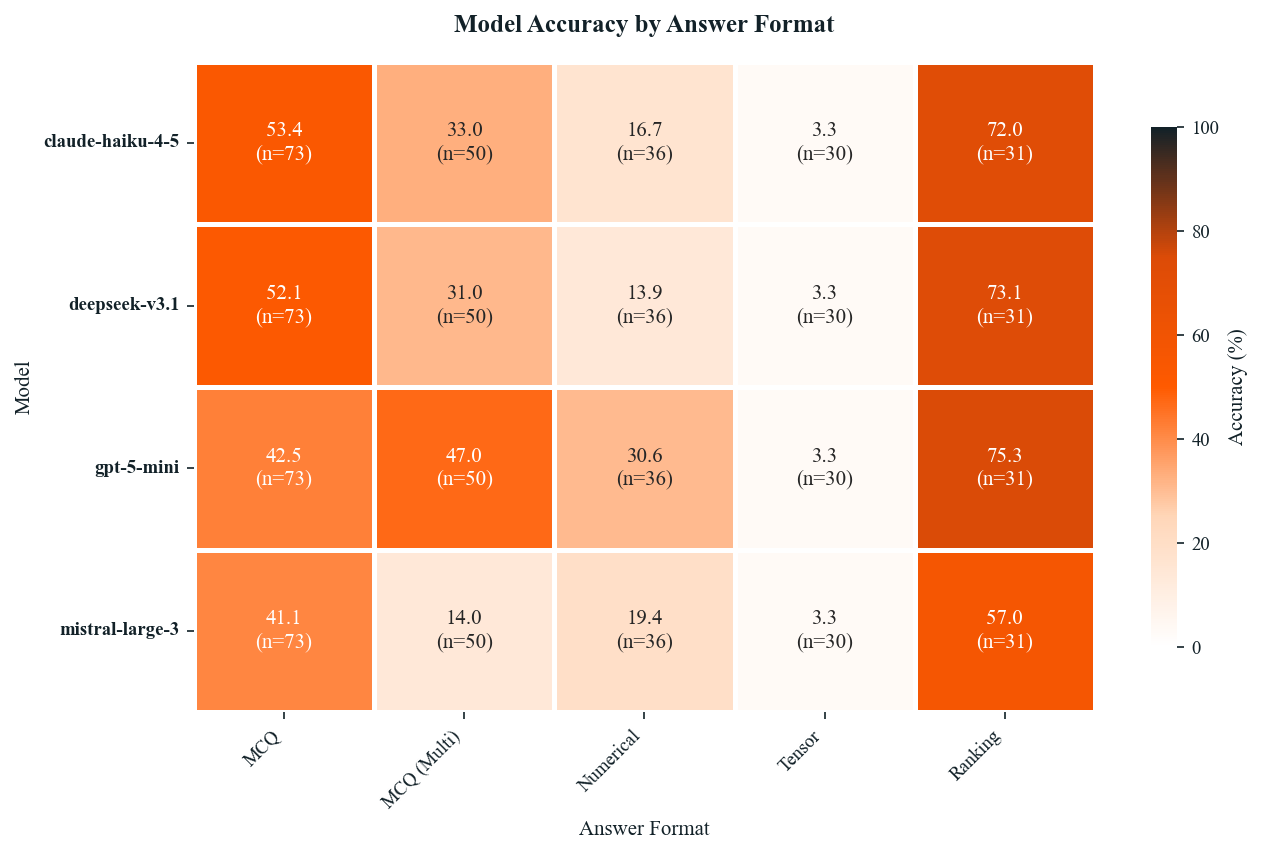

Saved: outputs\evaluation_figures\heatmap_models_x_formats.png


In [55]:
pivot_formats = df.groupby(["model", "answer_format"])["accuracy"].mean().unstack() * 100

fmt_cols = [f for f in FORMAT_ORDER if f in pivot_formats.columns]
extra = sorted(set(pivot_formats.columns) - set(FORMAT_ORDER))
pivot_formats = pivot_formats[fmt_cols + extra]

plot_heatmap(
    pivot_formats,
    title="Model Accuracy by Answer Format",
    xlabel="Answer Format",
    ylabel="Model",
    filename="heatmap_models_x_formats.png",
)

## 5, ROC-style Curve (Score Distribution / Threshold Sweep)

Since FactoryBench scoring is not binary classification, we produce a
**threshold–accuracy curve**: for each threshold *t* in [0, 1], we report
the fraction of predictions whose score ≥ *t*.

This shows how each model's score distribution degrades as we raise the
acceptance bar, analogous to a ROC curve.

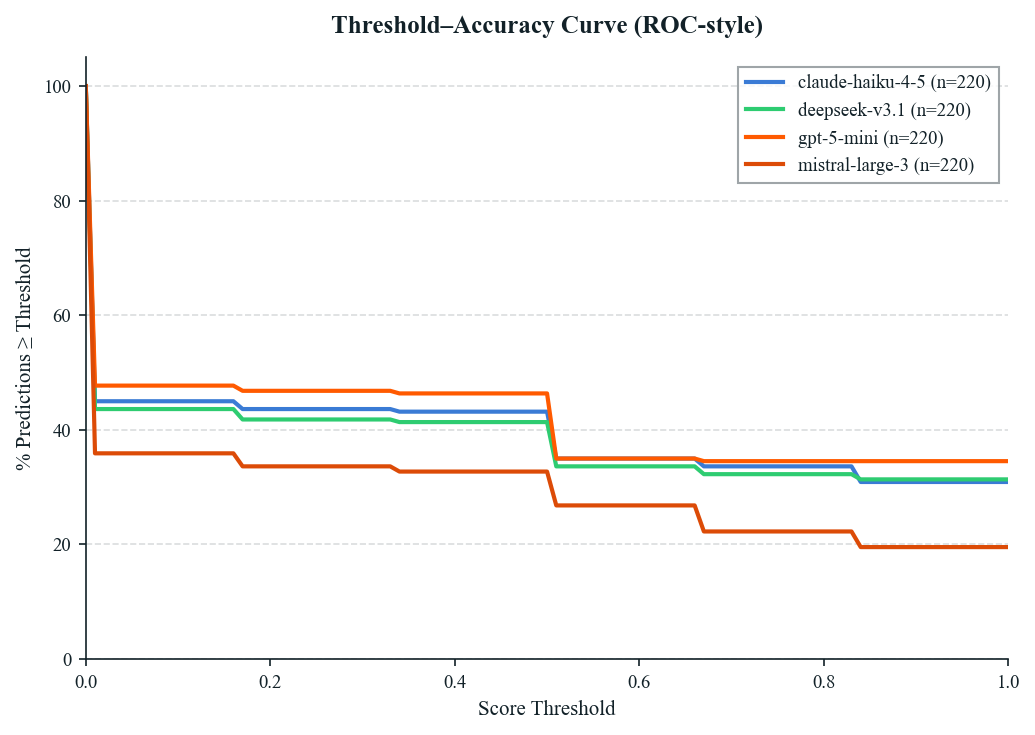

Saved: outputs\evaluation_figures\roc_threshold_curve.png


In [56]:
thresholds = np.linspace(0, 1, 101)
models = sorted(df["model"].unique())

fig, ax = plt.subplots(figsize=(7, 5))

for model in models:
    scores = df.loc[df["model"] == model, "accuracy"].values
    if len(scores) == 0:
        continue
    fractions = [(scores >= t).mean() * 100 for t in thresholds]
    color = MODEL_COLORS.get(model, STEEL)
    ax.plot(thresholds, fractions, label=f"{model} (n={len(scores)})", color=color, linewidth=2)

ax.set_xlabel("Score Threshold")
ax.set_ylabel("% Predictions ≥ Threshold")
ax.set_title("Threshold–Accuracy Curve (ROC-style)", fontweight="bold", pad=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 105)
ax.legend(loc="upper right", frameon=True, fancybox=False, edgecolor=STEEL)
ax.yaxis.grid(True, linestyle="--", alpha=0.3, color=STEEL)
ax.set_axisbelow(True)
fig.tight_layout()
out = FIGURES_DIR / "roc_threshold_curve.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

### 5b, ROC-style Curve per Answer Format

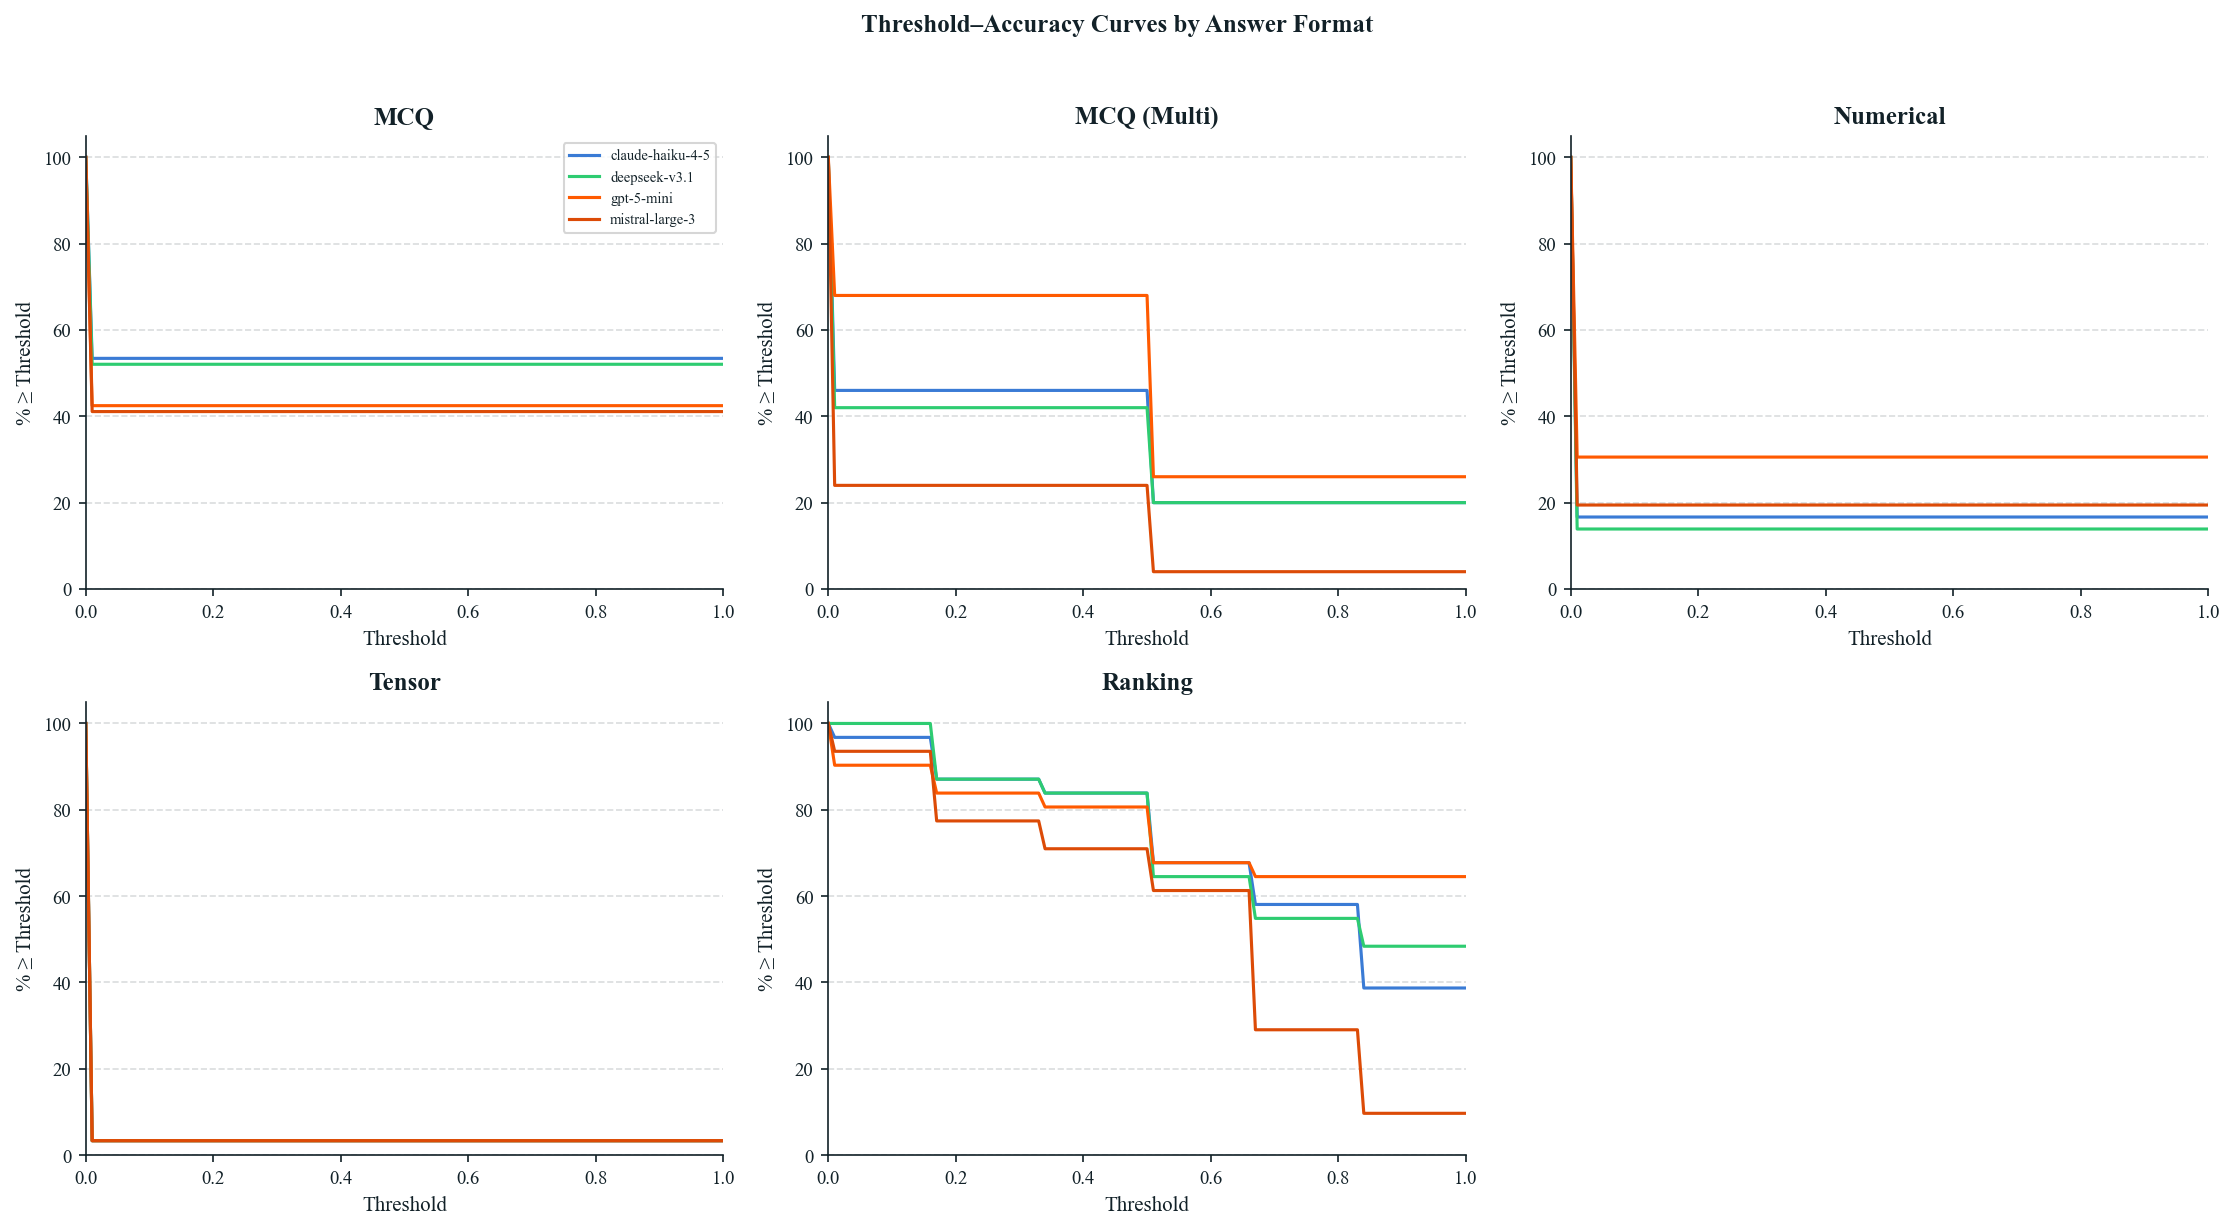

Saved: outputs\evaluation_figures\roc_threshold_by_format.png


In [57]:
formats_present = [f for f in FORMAT_ORDER if f in df["answer_format"].unique()]
n_fmts = len(formats_present)

if n_fmts > 0:
    n_cols = min(3, n_fmts)
    n_rows = (n_fmts + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

    for idx, fmt in enumerate(formats_present):
        ax = axes[idx // n_cols][idx % n_cols]
        df_fmt = df[df["answer_format"] == fmt]
        for model in models:
            scores = df_fmt.loc[df_fmt["model"] == model, "accuracy"].values
            if len(scores) == 0:
                continue
            fractions = [(scores >= t).mean() * 100 for t in thresholds]
            color = MODEL_COLORS.get(model, STEEL)
            ax.plot(thresholds, fractions, label=model, color=color, linewidth=1.5)
        ax.set_title(fmt, fontweight="bold")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 105)
        ax.set_xlabel("Threshold")
        ax.set_ylabel("% ≥ Threshold")
        ax.yaxis.grid(True, linestyle="--", alpha=0.3, color=STEEL)

    # Hide empty subplots
    for idx in range(n_fmts, n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].set_visible(False)

    axes[0][0].legend(fontsize=7, loc="upper right")
    fig.suptitle("Threshold–Accuracy Curves by Answer Format", fontweight="bold", y=1.02)
    fig.tight_layout()
    out = FIGURES_DIR / "roc_threshold_by_format.png"
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")
else:
    print("No answer formats found, skipping.")

## 7, Benchmark Table (Model × Level × Answer Format)

In [58]:
# Build a multi-level column table: (level, answer_format) with accuracy
table_data = []

for model in sorted(df["model"].unique()):
    row = {"Model": model}
    df_m = df[df["model"] == model]

    for level_key in LEVEL_ORDER:
        level_label = LEVEL_LABELS.get(level_key, level_key)
        df_ml = df_m[df_m["level"] == level_key]

        # Per-format accuracy
        for fmt in FORMAT_ORDER:
            df_mlf = df_ml[df_ml["answer_format"] == fmt]
            if len(df_mlf) > 0:
                acc = df_mlf["accuracy"].mean() * 100
                row[(level_label, fmt)] = f"{acc:.1f} (n={len(df_mlf)})"
            else:
                row[(level_label, fmt)] = ", "

        # Total for this level
        if len(df_ml) > 0:
            acc = df_ml["accuracy"].mean() * 100
            row[(level_label, "Total")] = f"{acc:.1f} (n={len(df_ml)})"
        else:
            row[(level_label, "Total")] = ", "

    # Overall total
    row[("Overall", "Total")] = f"{df_m['accuracy'].mean() * 100:.1f} (n={len(df_m)})"

    table_data.append(row)

# Build DataFrame with MultiIndex columns
model_col = [r["Model"] for r in table_data]

multi_cols = []
for level_key in LEVEL_ORDER:
    level_label = LEVEL_LABELS.get(level_key, level_key)
    for fmt in FORMAT_ORDER + ["Total"]:
        multi_cols.append((level_label, fmt))
multi_cols.append(("Overall", "Total"))

table_rows = []
for r in table_data:
    table_rows.append([r.get(col, ", ") for col in multi_cols])

col_index = pd.MultiIndex.from_tuples(multi_cols, names=["Level", "Format"])
benchmark_table = pd.DataFrame(table_rows, index=model_col, columns=col_index)
benchmark_table.index.name = "Model"

# Drop columns that are entirely ", "
mask = benchmark_table.ne(", ").any(axis=0)
benchmark_table = benchmark_table.loc[:, mask]

benchmark_table

Level                L1 State                                         \
Format                    MCQ   MCQ (Multi)    Numerical      Tensor   
Model                                                                  
claude-haiku-4-5  53.4 (n=73)  100.0 (n=10)  12.5 (n=16)  0.0 (n=10)   
deepseek-v3.1     52.1 (n=73)    0.0 (n=10)  12.5 (n=16)  0.0 (n=10)   
gpt-5-mini        42.5 (n=73)  100.0 (n=10)  12.5 (n=16)  0.0 (n=10)   
mistral-large-3   41.1 (n=73)   10.0 (n=10)  12.5 (n=16)  0.0 (n=10)   

Level                                       L2 Intervention               \
Format                Ranking         Total     MCQ (Multi)    Numerical   
Model                                                                      
claude-haiku-4-5  87.9 (n=11)  50.6 (n=120)     15.0 (n=20)  20.0 (n=10)   
deepseek-v3.1     84.8 (n=11)  41.1 (n=120)     25.0 (n=20)   0.0 (n=10)   
gpt-5-mini        89.4 (n=11)  44.0 (n=120)     27.5 (n=20)  40.0 (n=10)   
mistral-large-3   66.7 (n=11)  33.6 (n=120)     10.0 (n=20)  30.0 (n=10)   

Level                                                  L3 Counterfactual  \
Format                Tensor      Ranking        Total       MCQ (Multi)   
Model                                                                      
claude-haiku-4-5  0.0 (n=10)  71.7 (n=10)  24.3 (n=50)       17.5 (n=20)   
deepseek-v3.1     0.0 (n=10)  75.0 (n=10)  25.0 (n=50)       52.5 (n=20)   
gpt-5-mini        0.0 (n=10)  76.7 (n=10)  34.3 (n=50)       40.0 (n=20)   
mistral-large-3   0.0 (n=10)  50.0 (n=10)  20.0 (n=50)       20.0 (n=20)   

Level                                                                 \
Format              Numerical       Tensor      Ranking        Total   
Model                                                                  
claude-haiku-4-5  20.0 (n=10)  10.0 (n=10)  55.0 (n=10)  24.0 (n=50)   
deepseek-v3.1     30.0 (n=10)  10.0 (n=10)  58.3 (n=10)  40.7 (n=50)   
gpt-5-mini        50.0 (n=10)  10.0 (n=10)  58.3 (n=10)  39.7 (n=50)   
mistral-large-3   20.0 (n=10)  10.0 (n=10)  53.3 (n=10)  24.7 (n=50)   

Level                  Overall  
Format                   Total  
Model                           
claude-haiku-4-5  38.6 (n=220)  
deepseek-v3.1     37.3 (n=220)  
gpt-5-mini        40.8 (n=220)  
mistral-large-3   28.5 (n=220)

In [59]:
# Save table as LaTeX and CSV
latex_out = FIGURES_DIR / "benchmark_table.tex"
csv_out   = FIGURES_DIR / "benchmark_table.csv"

benchmark_table.to_latex(latex_out, multicolumn=True, multirow=True, escape=False)
benchmark_table.to_csv(csv_out)

print(f"LaTeX table saved: {latex_out}")
print(f"CSV table saved:   {csv_out}")

LaTeX table saved: outputs\evaluation_figures\benchmark_table.tex
CSV table saved:   outputs\evaluation_figures\benchmark_table.csv


## 7b, Render table as a figure

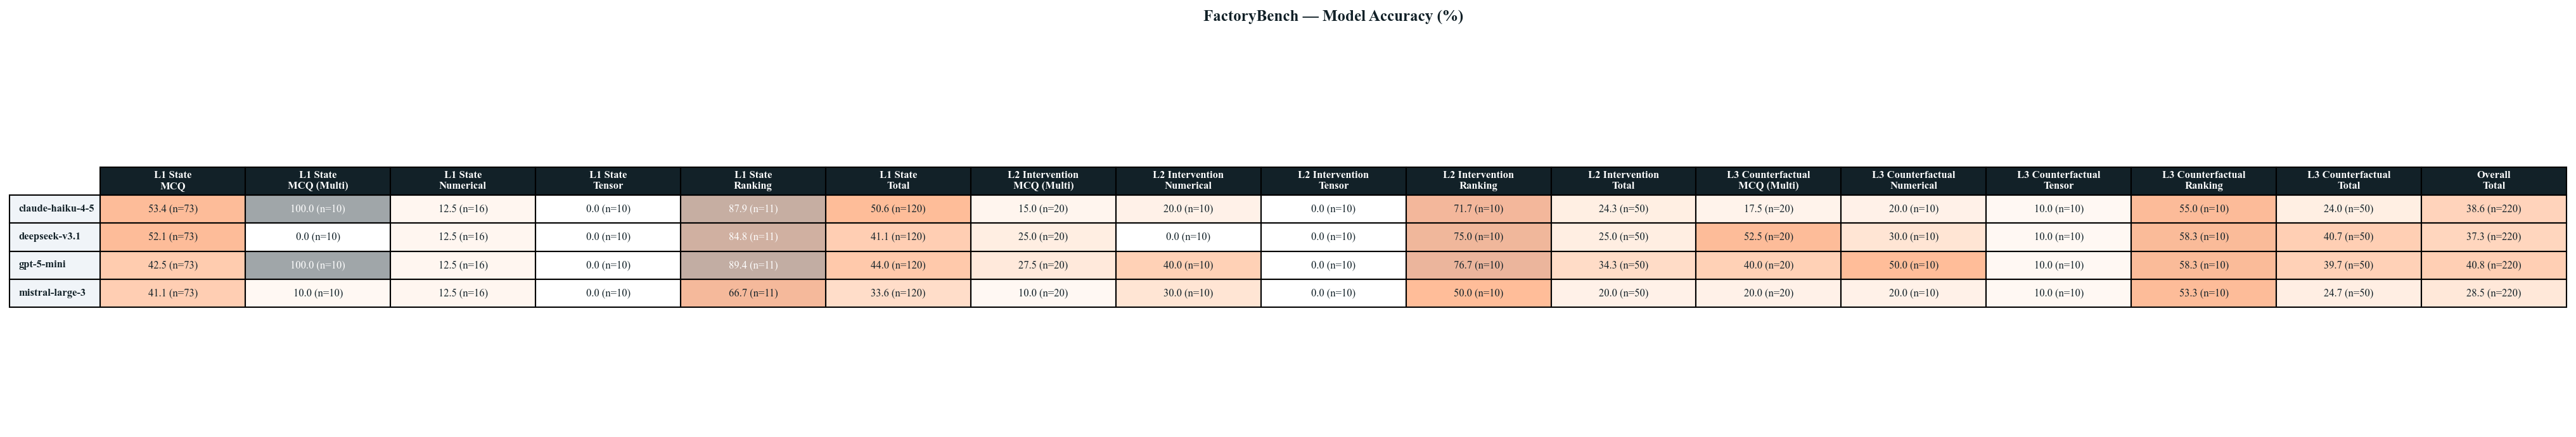

Saved: outputs\evaluation_figures\benchmark_table_figure.png


In [60]:
def render_table_figure(bench_df, filename):
    """Render the benchmark table as a matplotlib figure for the paper."""
    flat = bench_df.copy()
    flat.columns = [f"{l}\n{f}" for l, f in flat.columns]

    n_cols = len(flat.columns)
    n_rows = len(flat)

    fig, ax = plt.subplots(figsize=(max(12, n_cols * 1.6), max(2, n_rows * 0.8 + 1.5)))
    ax.axis("off")

    tbl = ax.table(
        cellText=flat.values,
        rowLabels=flat.index,
        colLabels=flat.columns,
        cellLoc="center",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1.0, 1.6)

    # Style header
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor(GUNMETAL)
            cell.set_text_props(color="white", fontweight="bold")
        elif col == -1:
            cell.set_facecolor("#F0F4F8")
            cell.set_text_props(fontweight="bold")
        else:
            text = cell.get_text().get_text()
            if text != ", ":
                try:
                    val = float(text.split("(")[0].strip())
                    norm = val / 100.0
                    r, g, b, _ = FORGIS_CMAP(norm)
                    lum = 0.299 * r + 0.587 * g + 0.114 * b
                    cell.set_facecolor((r, g, b, 0.4))
                    if lum < 0.4:
                        cell.set_text_props(color="white")
                except (ValueError, IndexError):
                    pass

    ax.set_title("FactoryBench, Model Accuracy (%)", fontweight="bold", fontsize=12, pad=20)
    fig.tight_layout()
    out = FIGURES_DIR / filename
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


render_table_figure(benchmark_table, "benchmark_table_figure.png")

## 9, Summary statistics

In [61]:
print("=" * 60)
print("Summary")
print("=" * 60)
print(f"Total traces with scores: {len(df)}")
print(f"Models evaluated:         {sorted(df['model'].unique())}")
print(f"Levels covered:           {sorted(df['level'].unique())}")
print(f"Answer formats:           {sorted(df['answer_format'].unique())}")
print(f"Total estimated cost:     ${df['cost'].sum():.4f}")
print()

# Per-model summary
summary = df.groupby("model").agg(
    n=("accuracy", "count"),
    mean_accuracy=("accuracy", "mean"),
    std_accuracy=("accuracy", "std"),
    cost=("cost", "sum"),
).reset_index()
summary["mean_accuracy"] = (summary["mean_accuracy"] * 100).round(2)
summary["std_accuracy"]  = (summary["std_accuracy"] * 100).round(2)
summary["cost"]          = summary["cost"].round(4)
summary.columns = ["Model", "N", "Acc (%)", "Std (%)", "Cost ($)"]
summary

Summary
Total traces with scores: 880
Models evaluated:         ['claude-haiku-4-5', 'deepseek-v3.1', 'gpt-5-mini', 'mistral-large-3']
Levels covered:           ['level_1', 'level_2', 'level_3']
Answer formats:           ['MCQ', 'MCQ (Multi)', 'Numerical', 'Ranking', 'Tensor']
Total estimated cost:     $85.7272



,Model,N,Acc (%),Std (%),Cost ($)
0,claude-haiku-4-5,220,38.56,45.57,27.4761
1,deepseek-v3.1,220,37.35,45.58,27.1185
2,gpt-5-mini,220,40.83,45.92,1.6893
3,mistral-large-3,220,28.48,41.31,29.4432


## 10, TS Foundation Models (Chronos-2 & Moirai)

Prediction-type questions (`state_signal_prediction`) are also evaluated with
time-series foundation models that consume the numeric series directly
instead of a text prompt. Those traces are tagged `ts_foundation` and carry
`signal_key`, `horizon_steps`, and the per-question `acceptance_bounds` in
their metadata.

The cells below fetch those traces, score them locally against the
per-question tolerance (falling back to ±10% of |gt| when no margin was
persisted), and compare Chronos-2 / Moirai against the chat LLMs on the
same prediction questions.

In [62]:
# TS foundation models use the Forgis brand palette defined at the top of
# the notebook. FIRE for Chronos-2 (warm) and PANEL for Moirai (cool) keep
# them visually distinct from the chat-LLM colors without introducing new
# hues.
TS_MODEL_COLORS = {
    "chronos-2": FIRE,
    "moirai":    PANEL,
}

TS_TAGS = ("ts_foundation", "chronos-2", "moirai")


def _to_float(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return None


def _score_prediction(pred, gt, margin, rel_fallback=0.10):
    """Score a prediction against gt using acceptance margin if available,
    else ±rel_fallback * max(|gt|, 1e-3)."""
    p, g = _to_float(pred), _to_float(gt)
    if p is None or g is None:
        return None, None
    err = abs(p - g)
    if margin is not None and margin > 0:
        tol = float(margin)
    else:
        tol = rel_fallback * max(abs(g), 1e-3)
    return float(err <= tol), err


ts_rows = []
for trace in traces:
    tags = set(trace.tags or [])
    metadata = trace.metadata or {}
    raw_model = (metadata.get("model") or "unknown").lower()
    model_name = MODEL_ALIASES.get(raw_model, raw_model)
    if "ts_foundation" not in tags and model_name not in TS_MODEL_IDS:
        continue

    inp = trace.input or {}
    feedback = {fb.name: fb.value for fb in (trace.feedback_scores or [])}

    level = "unknown"
    for tag in tags:
        if tag.startswith("level_"):
            level = tag
            break

    margin = (metadata.get("acceptance_bounds") or {}).get("margin")
    pred = inp.get("prediction")
    gt = inp.get("ground_truth")
    score, abs_err = _score_prediction(pred, gt, margin)
    # Prefer the accuracy feedback logged by the runner when present.
    if feedback.get("accuracy") is not None:
        score = float(feedback["accuracy"])

    ts_rows.append({
        "trace_id":      trace.id,
        "model":         model_name,
        "level":         level,
        "dataset":       metadata.get("dataset", ""),
        "episode":       metadata.get("episode", ""),
        "time_window":   _tw_key(metadata.get("time_window")),
        "signal_key":    metadata.get("signal_key"),
        "horizon_steps": metadata.get("horizon_steps"),
        "prediction":    _to_float(pred),
        "ground_truth":  _to_float(gt),
        "margin":        margin,
        "abs_error":     abs_err,
        "accuracy":      score,
    })

df_ts = pd.DataFrame(ts_rows)
df_ts = df_ts.dropna(subset=["accuracy"])

print(f"TS foundation traces: {len(df_ts)}")
if len(df_ts):
    print(f"Models: {sorted(df_ts['model'].unique())}")
    print(df_ts.groupby('model')['accuracy'].agg(['count', 'mean']).round(3))
else:
    print("(none, run the ts-eval stage first)")
df_ts.head()

TS foundation traces: 18
Models: ['chronos-2', 'moirai']
           count   mean
model                  
chronos-2      9  0.667
moirai         9  0.667


,trace_id,model,level,dataset,episode,time_window,signal_key,horizon_steps,prediction,ground_truth,margin,abs_error,accuracy
0,019dbcd8-6223-78e7-b5a9-ba419bd375b5,moirai,level_1,aursad,aursad_003,"(12690.0, 13440.0)",effort_current_5,3,-3.254389e-02,-0.0472,None,1.465611e-02,0.0
1,019dbcd8-5de8-7394-b74c-5387a0c017a3,moirai,level_1,aursad,aursad_007,"(10110.0, 10700.0)",feedback_vel_5,5,1.619065e-09,-0.0000,None,1.619065e-09,1.0
2,019dbcd8-5a20-796e-a24d-cec0dec12180,moirai,level_1,voraus,voraus_020,"(7850.653, 7985.56)",feedback_pos_0,1,9.061528e-01,0.9088,None,2.647215e-03,1.0
3,019dbcd8-5589-7282-929d-b63ca988b422,moirai,level_1,aursad,aursad_032,"(11710.0, 11840.0)",effort_current_4,4,-3.115585e-01,-0.4417,None,1.301415e-01,0.0
4,019dbcd8-51bb-76fc-ab09-490a2c29dafe,moirai,level_1,aursad,aursad_029,"(12250.0, 13410.0)",feedback_pos_4,1,-1.050000e+00,-1.0460,None,3.999952e-03,1.0


### 10a, Chronos-2 & Moirai accuracy heatmap

Accuracy of each TS foundation model broken down by sensor signal family
(motor current, joint position, joint velocity). Cells are annotated with
`accuracy%` and the per-cell sample size. Uses the Forgis brand colormap.

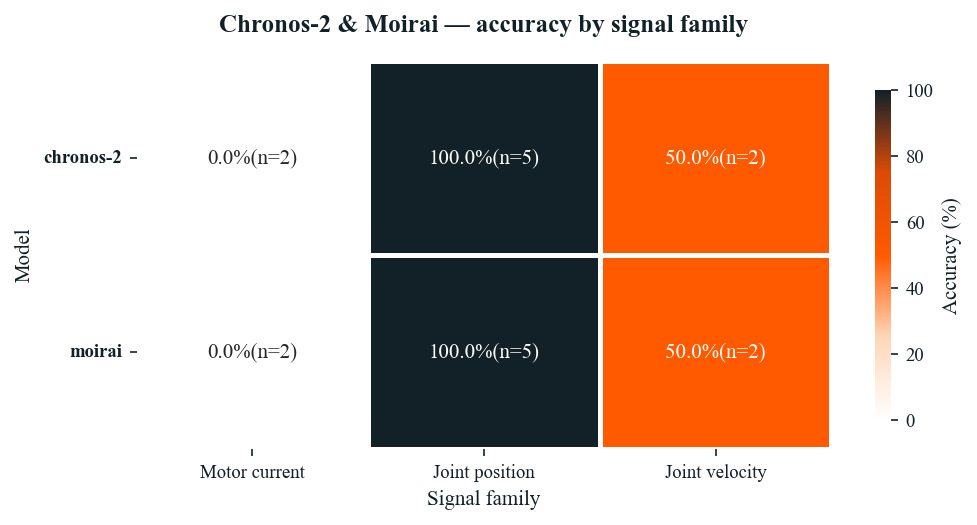

Saved: outputs\evaluation_figures\ts_foundation_heatmap.png
           n  accuracy_pct     mae  median_abs_err
model                                             
chronos-2  9         66.67  0.0203          0.0049
moirai     9         66.67  0.0184          0.0041


In [64]:
import re
if len(df_ts) == 0:
    print("No TS foundation traces found, skipping.")
else:
    # Derive a readable signal family from signal_key (e.g. "feedback_pos_4"
    # -> "feedback_pos"). The trailing axis index isn't informative for
    # aggregate accuracy, so strip it.
    SIGNAL_FAMILY_LABELS = {
        "effort_current": "Motor current",
        "feedback_pos":   "Joint position",
        "feedback_vel":   "Joint velocity",
        "feedback_speed": "Joint velocity",
    }
    SIGNAL_FAMILY_ORDER = ["Motor current", "Joint position", "Joint velocity"]

    def _signal_family(key):
        if not isinstance(key, str):
            return "Other"
        stem = re.sub(r"_\d+$", "", key)
        return SIGNAL_FAMILY_LABELS.get(stem, stem)

    df_ts_plot = df_ts.assign(signal_family=df_ts["signal_key"].map(_signal_family))
    ts_models = sorted(df_ts_plot["model"].unique())
    families = [f for f in SIGNAL_FAMILY_ORDER if f in df_ts_plot["signal_family"].unique()]
    families += sorted(set(df_ts_plot["signal_family"].unique()) - set(families))

    pivot_acc = (
        df_ts_plot.groupby(["model", "signal_family"])["accuracy"].mean()
        .unstack("signal_family")
        .reindex(index=ts_models, columns=families)
    ) * 100

    pivot_n = (
        df_ts_plot.groupby(["model", "signal_family"])["accuracy"].size()
        .unstack("signal_family")
        .reindex(index=ts_models, columns=families)
    ).fillna(0).astype(int)

    annot = pivot_acc.copy().astype(object)
    for m in pivot_acc.index:
        for f in pivot_acc.columns:
            val = pivot_acc.loc[m, f]
            n = int(pivot_n.loc[m, f])
            if pd.isna(val) or n == 0:
                annot.loc[m, f] = ""
            else:
                annot.loc[m, f] = f"{val:.1f}%(n={n})"

    n_rows, n_cols = pivot_acc.shape
    fig, ax = plt.subplots(figsize=(max(6, n_cols * 1.9 + 1.2), max(2.4, n_rows * 1.2 + 1.2)))
    sns.heatmap(
        pivot_acc.values.astype(float),
        annot=annot.values,
        fmt="",
        cmap=FORGIS_CMAP,
        vmin=0, vmax=100,
        linewidths=1.5, linecolor="white",
        cbar_kws={"label": "Accuracy (%)", "shrink": 0.85},
        ax=ax,
        mask=pd.isna(pivot_acc.values.astype(float)),
        xticklabels=pivot_acc.columns.tolist(),
        yticklabels=pivot_acc.index.tolist(),
    )
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_xlabel("Signal family")
    ax.set_ylabel("Model")
    ax.set_title("Chronos-2 & Moirai, accuracy by signal family",
                 fontweight="bold", pad=14)
    fig.tight_layout()
    out = FIGURES_DIR / "ts_foundation_heatmap.png"
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

    overall = (
        df_ts.groupby("model")
        .agg(n=("accuracy", "count"),
             accuracy_pct=("accuracy", lambda s: round(s.mean() * 100, 2)),
             mae=("abs_error", lambda s: round(s.mean(), 4)),
             median_abs_err=("abs_error", lambda s: round(s.median(), 4)))
        .reindex(ts_models)
    )
    print(overall)


### 10b, Absolute error distribution by forecast horizon

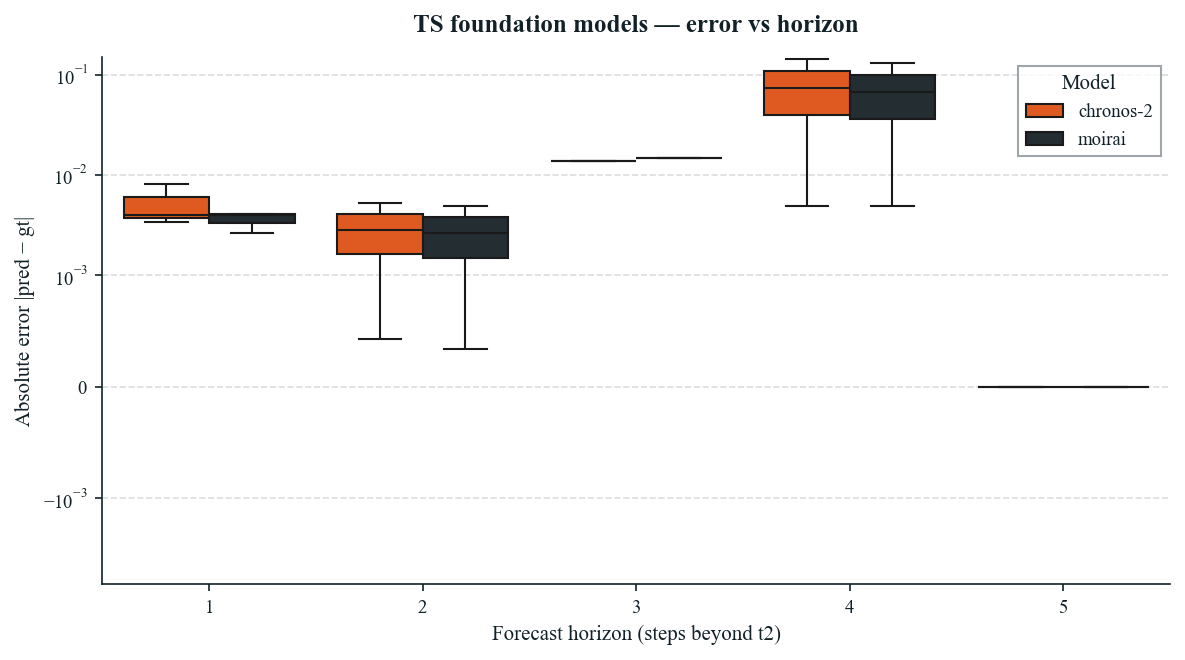

Saved: outputs\evaluation_figures\ts_foundation_error_by_horizon.png


In [ ]:
if len(df_ts) == 0:
    print("No TS foundation traces found, skipping.")
elif df_ts["horizon_steps"].isna().all():
    print("No horizon metadata, skipping.")
else:
    plot_df = df_ts.dropna(subset=["horizon_steps", "abs_error"]).copy()
    plot_df["horizon_steps"] = plot_df["horizon_steps"].astype(int)
    ts_models = sorted(plot_df["model"].unique())
    palette = {m: TS_MODEL_COLORS.get(m, STEEL) for m in ts_models}

    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.boxplot(
        data=plot_df,
        x="horizon_steps",
        y="abs_error",
        hue="model",
        order=sorted(plot_df["horizon_steps"].unique()),
        hue_order=ts_models,
        palette=palette,
        fliersize=3,
        linewidth=1.0,
        ax=ax,
    )
    ax.set_xlabel("Forecast horizon (steps beyond t2)")
    ax.set_ylabel("Absolute error |pred − gt|")
    ax.set_title("TS foundation models, error vs horizon",
                 fontweight="bold", pad=12)
    ax.set_yscale("symlog", linthresh=1e-3)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3, color=STEEL)
    ax.set_axisbelow(True)
    ax.legend(title="Model", frameon=True, fancybox=False, edgecolor=STEEL)
    fig.tight_layout()
    out = FIGURES_DIR / "ts_foundation_error_by_horizon.png"
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")